Industry-Style Agentic RAG with LangGraph
Why this is industry-style
A simple RAG system searches only the private knowledge base.

An industry-style Agentic RAG system should do this:

Question
  ↓
Search private knowledge base first
  ↓
Grade the private evidence
  ↓
If private evidence is good → answer from KB
  ↓
If private evidence is weak → search the web
  ↓
Grade web evidence
  ↓
Generate a grounded answer with source type
This design is useful because private documents may be incomplete or outdated.

1. Install Dependencies
2. Configure API Keys

In [234]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [235]:
import os
from getpass import getpass
from reranker import CrossEncoderReranker

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Enter GROQ_API_KEY: ")

if not os.getenv("TAVILY_API_KEY"):
    os.environ["TAVILY_API_KEY"] = getpass("Enter TAVILY_API_KEY: ")

if not os.getenv("PINECONE_API_KEY"):
    os.environ["PINECONE_API_KEY"] = getpass("Enter PINECONE_API_KEY: ")

print("GROQ_API_KEY configured:", bool(os.getenv("GROQ_API_KEY")))
print("TAVILY_API_KEY configured:", bool(os.getenv("TAVILY_API_KEY")))
print("PINECONE_API_KEY configured:", bool(os.getenv("PINECONE_API_KEY")))

GROQ_API_KEY configured: True
TAVILY_API_KEY configured: True
PINECONE_API_KEY configured: True


3. Load Real Documents
We will create our private knowledge base from a real web document:

https://docs.langchain.com/oss/python/langgraph/agentic-rag

This becomes our internal/private KB for the demo.

The web fallback is separate. That means:

First source: indexed LangGraph documentation page
Fallback source: live web search through Tavily

In [236]:
from langchain_community.document_loaders import WebBaseLoader

SOURCE_URL = "https://docs.langchain.com/oss/python/langgraph/agentic-rag"

loader = WebBaseLoader(
    web_paths=(SOURCE_URL,),
    requests_kwargs={
        "headers": {
            "User-Agent": "Mozilla/5.0 Agentic-RAG-Industry-Demo"
        }
    },
)

raw_docs = loader.load()

print("Loaded documents:", len(raw_docs))
print("Source:", raw_docs[0].metadata.get("source"))
print("\nPreview:\n")
print(raw_docs[0].page_content[:1500])

Loaded documents: 1
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag

Preview:

Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyCa

4. Split the Documents into Chunks

In [237]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    add_start_index=True,
)

chunks = splitter.split_documents(raw_docs)

print("Total chunks:", len(chunks))
print("\nFirst chunk preview:\n")
print(chunks[0].page_content[:900])

Total chunks: 28

First chunk preview:

Build a custom RAG agent with LangGraph - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what's next for agents. Get your tickets →Docs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraphBuild a custom RAG agent with LangGraphOverviewDeep AgentsManaged Deep AgentsLangChainLangGraphOpenWikiIntegrationsLearnReferenceContributePythonLearnTutorialsDeep AgentsLangChainMulti-agentLangGraphCustom RAG agentCustom SQL agentConceptual overviewsLangChain vs. LangGraph vs. Deep AgentsProviders and modelsComponent architectureMemoryContextGraph APIFunctional APIAdditional resourcesUse docs programmaticallyLangChain AcademyC


5. Create Free Local Embeddings

In [238]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"normalize_embeddings": True},
)

sample_vector = embeddings.embed_query("What is Agentic RAG?")
print("Embedding dimensions:", len(sample_vector))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7615.25it/s]


Embedding dimensions: 384


6. Create the Pinecone Vector Database

In [239]:
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
import time

INDEX_NAME = "industry-agentic-rag-kb"
NAMESPACE = "langgraph-agentic-rag"

# Connect to Pinecone
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])

# Create the index only if it does not already exist.
existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]

if INDEX_NAME not in existing_indexes:
    pc.create_index(
        name=INDEX_NAME,
        dimension=384,       # all-MiniLM-L6-v2 embedding dimension
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1",
        ),
    )

    # Wait until Pinecone reports the new index as ready.
    while not pc.describe_index(INDEX_NAME).status["ready"]:
        time.sleep(1)

print("Pinecone index ready:", INDEX_NAME)

# Upload the document chunks and create the LangChain vector store.
vectorstore = PineconeVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    index_name=INDEX_NAME,
    namespace=NAMESPACE,
)

RETRIEVAL_TOP_K = 15
RERANK_TOP_N = 5

retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": RETRIEVAL_TOP_K,
        "namespace": NAMESPACE,
    }
)
print("Pinecone vector database and retriever are ready.")

Pinecone index ready: industry-agentic-rag-kb
Pinecone vector database and retriever are ready.


In [240]:
# Load Existing Index

from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore
from reranker import CrossEncoderReranker

INDEX_NAME = "industry-agentic-rag-kb"
NAMESPACE = "langgraph-agentic-rag"

# Connect to Pinecone
pc = Pinecone(api_key=os.environ["PINECONE_API_KEY"])

# Load existing Pinecone index
index = pc.Index(INDEX_NAME)

# Connect existing index with LangChain
vectorstore = PineconeVectorStore(
    index=index,
    embedding=embeddings,
    namespace=NAMESPACE,
)

RETRIEVAL_TOP_K = 15
RERANK_TOP_N = 5

retriever = vectorstore.as_retriever(
    search_kwargs={
        "k": RETRIEVAL_TOP_K,
        "namespace": NAMESPACE,
    }
)

print("Existing Pinecone index loaded:", INDEX_NAME)

Existing Pinecone index loaded: industry-agentic-rag-kb


7. Test Private KB Retrieval

In [241]:
test_question = "What happens if retrieved documents are not relevant in Agentic RAG?"

kb_docs = retriever.invoke(test_question)

for i, doc in enumerate(kb_docs, 1):
    print(f"\n--- KB RESULT {i} ---")
    print("Source:", doc.metadata.get("source"))
    print(doc.page_content[:700])


--- KB RESULT 1 ---
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag
docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCreate a retriever toolGenerate a query or respondGrade documentsRewrite the questionGenerate an answerAssemble the graphRun the agentic RAGSee alsoTutorialsLangGraphBuild a custom RAG agent with LangGraphCopy pageCopy pageBuild a custom retrieval agent with LangGraph that decides when to search a vector store or respond directly.Copy pageCopy pageBuild a retrieval agent with LangGraph that decides when to search a vector store versus answering the user directly.

--- KB RESULT 2 ---
Source: https://docs.langchain.com/oss/python/langgraph/agentic-rag
docs programmaticallyLangChain AcademyCase studiesGet helpOn this pageConceptsSetupSet up LangSmithPreprocess documentsCreate a retriever toolGenerate a query or respondGrade documentsRewrite the questionGenerate an answerAssemble the 

8. Initialize Groq LLM

In [242]:
from langchain_groq import ChatGroq

# Replace this model if your Groq dashboard shows a different available model.
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

print(llm.invoke("Explain Agentic RAG in one sentence.").content)

Agentic RAG is a retrieval‑augmented generation framework in which an autonomous agent actively queries, selects, and incorporates relevant external documents to inform and improve its generated responses.


9. Initialize Tavily Web Search
Tavily will be used only when the private knowledge base is insufficient.

This is important because we do not want to send every private/company question to the public web.

In [243]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=5,
    topic="general",
    include_answer=True,
    include_raw_content=False,
)

print("Tavily search tool ready.")

Tavily search tool ready.


Initialize Groq LLM

In [244]:
from langchain_groq import ChatGroq

# Replace this model if your Groq dashboard shows a different available model.
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
)

print(llm.invoke("Explain Agentic RAG in one sentence.").content)

Agentic RAG is a retrieval‑augmented generation framework in which an autonomous agent actively queries, selects, and incorporates relevant external documents to inform and improve its generated responses.


Step 1 — Update imports and state

In [245]:
from typing import List, Literal

from typing_extensions import TypedDict

from pydantic import BaseModel, Field

from langchain_core.documents import Document

Route model

In [246]:
class RouteDecision(BaseModel):

    route: Literal["kb", "direct"] = Field(
        description=(
            "Use kb for questions requiring private Agentic RAG "
            "knowledge-base documents. Use direct for greetings, "
            "thanks, or simple conversation."
        )
    )

Step 2 — Upgrade EvidenceGrade for CRAG

In [247]:
class EvidenceGrade(BaseModel):

    grade: Literal["good", "weak"] = Field(
        ...,
        description=(
            "good means the evidence is relevant and sufficient "
            "to answer the question. weak means the evidence is "
            "irrelevant, insufficient, or incomplete."
        )
    )

    score: float = Field(
        ...,
        ge=0.0,
        le=1.0,
        description="Evidence relevance score between 0 and 1."
    )

    reason: str = Field(
        ...,
        description="Explain why the evidence was graded as good or weak."
    )

Step 3 — Add the Self-RAG evaluator model

In [248]:
class AnswerGrade(BaseModel):

    groundedness_score: float = Field(
        ...,
        ge=0.0,
        le=1.0,
        description=(
            "Measures whether the answer is supported by "
            "the retrieved evidence."
        )
    )

    completeness_score: float = Field(
        ...,
        ge=0.0,
        le=1.0,
        description=(
            "Measures whether the answer completely addresses "
            "the user's question."
        )
    )

    citation_score: float = Field(
        ...,
        ge=0.0,
        le=1.0,
        description=(
            "Measures whether the answer's sources/citations "
            "are supported by the evidence."
        )
    )

    decision: Literal["pass", "retry"] = Field(
        ...,
        description=(
            "pass if the answer is sufficiently grounded and complete. "
            "retry if the answer needs correction."
        )
    )

    feedback: str = Field(
        ...,
        description="Explain why the answer passed or needs correction."
    )

Step 4 — AgentState

In [249]:
class AgentState(TypedDict):

    # ============================================================
    # USER QUERY
    # ============================================================

    question: str

    # Query used for current retrieval.
    # This changes after query rewriting.
    current_query: str


    # ============================================================
    # KB RETRIEVAL
    # ============================================================

    kb_docs: List[Document]


    # ============================================================
    # WEB RETRIEVAL
    # ============================================================

    web_results: str


    # ============================================================
    # CRAG - KB EVALUATION
    # ============================================================

    kb_grade: Literal["good", "weak"]

    kb_relevance_score: float


    # ============================================================
    # CRAG - WEB EVALUATION
    # ============================================================

    web_grade: Literal["good", "weak"]

    web_relevance_score: float


    # ============================================================
    # GENERATION
    # ============================================================

    answer: str

    source_used: str


    # ============================================================
    # SELF-RAG
    # ============================================================

    groundedness_score: float

    completeness_score: float

    citation_score: float

    answer_grade: Literal["pass", "retry"]

    answer_feedback: str


    # ============================================================
    # RETRY CONTROL
    # ============================================================

    retry_count: int

    max_retries: int

Step 5 — Router

In [250]:
router_llm = llm.with_structured_output(
    RouteDecision,
    method="json_mode"
)


def route_question(state: AgentState) -> AgentState:

    question = state["current_query"]

    router_prompt = f"""
You are a router for an Agentic RAG assistant.

Route to "kb" if the question requires information from
the private knowledge base, such as:

- Agentic RAG
- LangGraph Agentic RAG workflow
- retrieval grading
- query rewriting
- RAG architecture
- retriever tools
- web fallback in RAG
- Self-RAG
- Corrective RAG
- CRAG
- internal technical documentation

Route to "direct" only for:

- greetings
- thanks
- casual conversation
- very simple questions that do not require retrieval

Question:
{question}

Return valid JSON.

Example:
{{"route": "kb"}}
"""

    route_decision = router_llm.invoke(router_prompt)

    print(
        f"[Router] Question: {question}"
    )

    print(
        f"[Router] Decision: {route_decision.route}"
    )

    return {
        "source_used": route_decision.route,
        "current_query": question
    }

Step 6 — Router conditional

In [251]:
def route_after_router(
    state: AgentState
) -> Literal["retrieve_kb", "direct_answer"]:

    if state["source_used"] == "kb":
        return "retrieve_kb"

    return "direct_answer"

Step 7 — KB retrieval

In [252]:
def retrieve_kb(state: AgentState):

    question = state["current_query"]

    print(f"[KB Retriever] Query: {question}")

    # 1. Vector retrieval
    candidate_docs = retriever.invoke(question)

    print(
        f"[KB Retriever] Retrieved candidates: "
        f"{len(candidate_docs)}"
    )

    # 2. Reranking
    reranked_docs = reranker.rerank(
        query=question,
        documents=candidate_docs,
    )

    # 3. Extract reranked documents
    final_docs = [
        document
        for document, score in reranked_docs
    ]

    print(
        f"[Reranker] Selected: "
        f"{len(final_docs)} documents"
    )

    for index, (document, score) in enumerate(
        reranked_docs,
        start=1,
    ):
        print(
            f"[Reranker] #{index} "
            f"score={score:.4f}"
        )

    return {
        "kb_docs": final_docs
    }

Step 8 — CRAG KB evaluator

In [253]:
kb_grader_llm = llm.with_structured_output(
    EvidenceGrade,
    method="json_mode"
)


def grade_kb_evidence(state: AgentState) -> AgentState:

    question = state["current_query"]
    kb_docs = state["kb_docs"]

    if not kb_docs:

        print("[KB Grader] No KB documents retrieved.")

        return {
            "kb_grade": "weak",
            "kb_relevance_score": 0.0
        }

    context = "\n\n".join(
        f"Source: {doc.metadata.get('source')}\n"
        f"{doc.page_content}"
        for doc in kb_docs
    )

    grading_prompt = f"""
You are an evidence grader for a RAG system.

Evaluate whether the retrieved evidence is relevant and sufficient
to answer the user's question.

Question:
{question}

Private KB Evidence:
{context}

Rules:

1. grade must be exactly "good" or "weak".
2. "good" means the evidence is relevant and sufficient.
3. "weak" means the evidence is irrelevant, insufficient, or incomplete.
4. score must be between 0.0 and 1.0.
5. reason must explain the grading decision.

IMPORTANT:
Return ONLY valid JSON.

The JSON MUST contain exactly these fields:

{{
    "grade": "good",
    "score": 0.95,
    "reason": "The evidence directly answers the question."
}}

Do NOT use "evaluation".
Do NOT omit "grade".
Do NOT omit "score".
Do NOT omit "reason".
"""

    grade_decision = kb_grader_llm.invoke(
        grading_prompt
    )

    print("[KB Grader]")
    print("Grade:", grade_decision.grade)
    print("Score:", grade_decision.score)
    print("Reason:", grade_decision.reason)

    return {
        "kb_grade": grade_decision.grade,
        "kb_relevance_score": grade_decision.score
    }

Step 9 — Change KB grading decision

In [254]:
def decide_after_kb_grade(
    state: AgentState
) -> Literal["generate_from_kb", "search_web"]:

    if state["kb_grade"] == "good":
        return "generate_from_kb"

    return "search_web"

Step 10 — Query rewriting

In [255]:
def rewrite_query(state: AgentState) -> AgentState:

    question = state["current_query"]

    retries = state.get("retry_count", 0) + 1

    rewrite_prompt = f"""
You are a query optimization agent for an Agentic RAG system.

Rewrite the query so that the retriever can find more
relevant information.

Rules:

- Preserve the original intent.
- Do not change the meaning.
- Add useful technical terminology when appropriate.
- Make the query specific.
- Remove unnecessary conversational wording.
- Do not answer the question.
- Return only the rewritten query.

Original query:
{question}
"""

    rewritten_query = (
        llm.invoke(rewrite_prompt)
        .content
        .strip()
    )

    print(
        f"[Query Rewriter] Original: {question}"
    )

    print(
        f"[Query Rewriter] Rewritten: {rewritten_query}"
    )

    return {
        "current_query": rewritten_query,
        "retry_count": retries
    }

Step 11 — We need a decision after the corrected KB retrieval

In [256]:

MAX_RETRIES = 1

def decide_after_kb_grade(
    state: AgentState
) -> Literal[
    "generate_from_kb",
    "rewrite_query",
    "search_web"
]:

    if state["kb_grade"] == "good":

        return "generate_from_kb"

    if state["retry_count"] < MAX_RETRIES:

        return "rewrite_query"

    return "search_web"

Step 12 — Web search

In [257]:
def search_web(state: AgentState) -> AgentState:

    query = state["current_query"]

    print(
        f"[Tavily Search] Query: {query}"
    )

    result = web_search.invoke(
        {"query": query}
    )

    if isinstance(result, dict):

        answer = result.get("answer", "")

        results = result.get("results", [])

        lines = []

        if answer:

            lines.append(
                f"Tavily answer: {answer}"
            )

        for item in results:

            title = item.get("title", "")

            url = item.get("url", "")

            content = item.get("content", "")

            lines.append(
                f"Title: {title}\n"
                f"URL: {url}\n"
                f"Content: {content}"
            )

        web_text = (
            "\n\n".join(lines)
            if lines
            else str(result)
        )

    else:

        web_text = str(result)

    print(
        "[Tavily Search] Result characters:",
        len(web_text)
    )

    return {
        "web_results": web_text,
        "source_used": "web"
    }

Step 13 — Web evidence grader

In [258]:
web_grader_llm = llm.with_structured_output(
    EvidenceGrade,
    method="json_mode"
)


def grade_web_evidence(state: AgentState):

    question = state["question"]
    web_results = state["web_results"]

    grading_prompt = f"""
You are an evidence grader for a RAG system.

Evaluate whether the retrieved evidence is relevant and sufficient
to answer the user's question.

Question:
{question}

Web Search Evidence:
{web_results}

Rules:

- grade must be exactly either "good" or "weak".
- Use "good" when the evidence is relevant and sufficient.
- Use "weak" when the evidence is irrelevant, insufficient, or incomplete.
- score must be a number between 0.0 and 1.0.
- reason must explain why the evidence was graded as good or weak.

IMPORTANT:
Return ONLY a JSON object.

The JSON MUST contain exactly these fields:

{{
    "grade": "good",
    "score": 0.95,
    "reason": "The evidence directly answers the question."
}}

Do NOT use the field name "evaluation".
Do NOT omit "reason".
Do NOT add extra fields
"""

    grade = web_grader_llm.invoke(grading_prompt)

    print("[Web Grader]")
    print("Grade:", grade.grade)
    print("Score:", grade.score)
    print("Reason:", grade.reason)

    return {
        "web_grade": grade.grade,
        "web_relevance_score": grade.score
    }

Step 14 — Web decision

In [259]:
def decide_after_web_grade(
    state: AgentState
) -> Literal[
    "generate_from_web",
    "rewrite_query",
    "answer_insufficient"
]:

    if state["web_grade"] == "good":

        return "generate_from_web"

    if state["retry_count"] < MAX_RETRIES:

        return "rewrite_query"

    return "answer_insufficient"

Step 15 — Generate from KB

In [260]:
def generate_from_kb(state: AgentState) -> AgentState:

    question = state["question"]

    kb_docs = state["kb_docs"]

    context = "\n\n".join(
        f"""
Source:
{doc.metadata.get('source', 'Unknown')}

Content:
{doc.page_content}
"""
        for doc in kb_docs
    )

    answer_prompt = f"""
You are a technical instructor.

Answer the user's question using ONLY
the private KB context.

Rules:

- Answer the original user question.
- Use only information supported by the context.
- Do not hallucinate.
- Do not introduce external knowledge.
- Explain clearly and professionally.
- Mention that the answer is based on the private KB.
- Include source information when available.

Original Question:
{question}

Private KB Context:
{context}
"""

    kb_answer = (
        llm.invoke(answer_prompt)
        .content
        .strip()
    )

    print(
        "[KB Generator] Generated answer from private KB."
    )

    return {
        "answer": kb_answer,
        "source_used": "private_kb"
    }

Step 16 — Generate from web

In [261]:
def generate_from_web(state: AgentState) -> AgentState:

    question = state["question"]

    web_context = state["web_results"]

    answer = llm.invoke(
        f"""
You are a technical instructor.

The private knowledge base was insufficient,
so web search was used.

Answer the original user question using
ONLY the web search context.

Rules:

- Do not hallucinate.
- Do not use knowledge outside the supplied web context.
- Clearly explain the answer.
- Mention that web search was used.
- Include useful URLs from the context when available.

Original Question:
{question}

Web Search Context:
{web_context}
"""
    ).content.strip()

    print(
        "[Web Generator] Generated answer from web."
    )

    return {
        "answer": answer,
        "source_used": "web_search"
    }

In [262]:
#  grade_answer

def grade_answer(state: AgentState) -> AgentState:

    question = state["question"]
    answer = state["answer"]

    kb_docs = state.get("kb_docs", [])
    web_results = state.get("web_results", "")

    kb_context = "\n\n".join(
        f"Source: {doc.metadata.get('source')}\n"
        f"{doc.page_content}"
        for doc in kb_docs
    )

    prompt = f"""
You are a Self-RAG answer evaluator.

Evaluate the generated answer against the user's question and
the retrieved evidence.

Question:
{question}

Generated Answer:
{answer}

Private KB Evidence:
{kb_context}

Web Evidence:
{web_results}

Evaluate:

- groundedness_score: 0.0 to 1.0
- completeness_score: 0.0 to 1.0
- citation_score: 0.0 to 1.0
- decision: "pass" or "retry"
- feedback: explain the decision

Use EXACTLY these JSON field names:

{{
    "groundedness_score": 0.85,
    "completeness_score": 1.0,
    "citation_score": 1.0,
    "decision": "pass",
    "feedback": "The answer is sufficiently grounded and complete."
}}

Do NOT use:
"groundedness"
"completeness"
"citation"

Use:
"groundedness_score"
"completeness_score"
"citation_score"

Return ONLY valid JSON.
"""

    result = answer_grader_llm.invoke(prompt)

    print("[Self-RAG Grader]")
    print("Groundedness:", result.groundedness_score)
    print("Completeness:", result.completeness_score)
    print("Citation:", result.citation_score)
    print("Decision:", result.decision)
    print("Feedback:", result.feedback)

    return {
        "groundedness_score": result.groundedness_score,
        "completeness_score": result.completeness_score,
        "citation_score": result.citation_score,
        "answer_grade": result.decision,
        "answer_feedback": result.feedback
    }

Step 17 — Direct answer

In [263]:
def direct_answer(state: AgentState) -> AgentState:

    question = state["question"]

    answer = llm.invoke(
        f"""
Respond briefly and naturally.

Message:
{question}
"""
    ).content.strip()

    return {
        "answer": answer,
        "source_used": "direct"
    }

Step 18 — Add Self-RAG evaluator

In [264]:
answer_grader_llm = llm.with_structured_output(
    AnswerGrade,
    method="json_mode"
)


def evaluate_answer(state: AgentState) -> AgentState:

    question = state["question"]

    answer = state["answer"]

    source_used = state["source_used"]

    kb_docs = state.get("kb_docs", [])

    web_results = state.get("web_results", "")


    # ------------------------------------------------------------
    # Build evidence
    # ------------------------------------------------------------

    kb_context = "\n\n".join(
        f"""
Source:
{doc.metadata.get('source', 'Unknown')}

Content:
{doc.page_content}
"""
        for doc in kb_docs
    )


    evaluation_prompt = f"""
You are a Self-RAG answer evaluator.

Your job is to evaluate whether the generated answer
is trustworthy and properly supported by the available evidence.

Original Question:
{question}

Generated Answer:
{answer}

Answer Source:
{source_used}

Private KB Evidence:
{kb_context}

Web Evidence:
{web_results}


Evaluate the answer using these dimensions.


1. GROUNDEDNESS

Are the claims in the answer supported by the available evidence?

1.0 = fully supported
0.0 = unsupported/hallucinated


2. COMPLETENESS

Does the answer actually address the user's question?

1.0 = completely answers the question
0.0 = does not answer it


3. CITATION

Are the source references/citations consistent
with the evidence?

1.0 = fully supported
0.0 = unsupported


PASS CRITERIA:

groundedness >= 0.80
completeness >= 0.80
citation >= 0.80


If all criteria pass:

decision = "pass"

Otherwise:

decision = "retry"


Return valid JSON.
"""

    result = answer_grader_llm.invoke(
        evaluation_prompt
    )

    print(
        "[Self-RAG] Groundedness:",
        result.groundedness_score
    )

    print(
        "[Self-RAG] Completeness:",
        result.completeness_score
    )

    print(
        "[Self-RAG] Citation:",
        result.citation_score
    )

    print(
        "[Self-RAG] Decision:",
        result.decision
    )

    print(
        "[Self-RAG] Feedback:",
        result.feedback
    )

    return {

        "groundedness_score":
            result.groundedness_score,

        "completeness_score":
            result.completeness_score,

        "citation_score":
            result.citation_score,

        "answer_grade":
            result.decision,

        "answer_feedback":
            result.feedback
    }

Step 19 — Self-RAG decision

In [265]:
def decide_after_self_rag(
    state: AgentState
) -> Literal[
    "end",
    "self_correct"
]:

    if state["answer_grade"] == "pass":

        print("[Self-RAG] Answer passed evaluation.")

        return "end"


    if state["retry_count"] < state["max_retries"]:

        print(
            "[Self-RAG] Answer failed. "
            "Starting corrective cycle."
        )

        return "self_correct"


    print(
        "[Self-RAG] Maximum retries reached."
    )

    return "end"

Step 20 — Self-correction node

In [266]:
def self_correct(state: AgentState) -> AgentState:

    question = state["question"]

    feedback = state["answer_feedback"]

    current_query = state["current_query"]

    retries = state.get("retry_count", 0) + 1


    correction_prompt = f"""
You are a corrective retrieval agent in a Self-RAG system.

The generated answer failed evaluation.

Original Question:
{question}

Current Retrieval Query:
{current_query}

Self-RAG Feedback:
{feedback}

Create a better retrieval query that addresses
the evaluator's feedback.

Rules:

- Preserve the original question intent.
- Focus on missing evidence.
- Remove unsupported assumptions.
- Make the query precise.
- Do not answer the question.
- Return only the improved retrieval query.
"""

    corrected_query = (
        llm.invoke(correction_prompt)
        .content
        .strip()
    )

    print(
        "[Self-Correction] Previous query:",
        current_query
    )

    print(
        "[Self-Correction] New query:",
        corrected_query
    )

    return {

        "current_query": corrected_query,

        "retry_count": retries,

        # Clear old evidence before retrieval.
        "kb_docs": [],

        "web_results": "",

        "answer": "",

        "answer_feedback": ""
    }

Step 21 — Insufficient answer

In [267]:
def answer_insufficient(state: AgentState) -> AgentState:

    answer = (
        "I could not find enough reliable evidence in "
        "the private knowledge base or web search results "
        "to answer this confidently. "
        "Please provide more specific information or "
        "rephrase the question."
    )

    return {
        "answer": answer,
        "source_used": "insufficient_evidence"
    }

In [268]:
def decide_after_answer_grade(state: AgentState) -> str:

    # Self-RAG says answer is good
    if state["answer_grade"] == "pass":
        return "end"

    # Answer needs correction
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 1)

    if retry_count < max_retries:
        return "rewrite_query"

    # Maximum retry reached
    return "answer_insufficient"

Step 22 — Now update the graph

In [269]:
from langgraph.graph import StateGraph, START, END

# Create a NEW graph
workflow = StateGraph(AgentState)


# =========================
# NODES
# =========================

workflow.add_node("route_question", route_question)
workflow.add_node("retrieve_kb", retrieve_kb)
workflow.add_node("grade_kb_evidence", grade_kb_evidence)
workflow.add_node("search_web", search_web)
workflow.add_node("grade_web_evidence", grade_web_evidence)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_from_kb", generate_from_kb)
workflow.add_node("generate_from_web", generate_from_web)
workflow.add_node("direct_answer", direct_answer)
workflow.add_node("grade_answer", grade_answer)
workflow.add_node("answer_insufficient", answer_insufficient)


# =========================
# EDGES
# =========================

workflow.add_edge(
    START,
    "route_question"
)


workflow.add_conditional_edges(
    "route_question",
    route_after_router,
    {
        "retrieve_kb": "retrieve_kb",
        "direct_answer": "direct_answer",
    }
)


workflow.add_edge(
    "retrieve_kb",
    "grade_kb_evidence"
)


# IMPORTANT:
# This now contains ALL THREE possible outputs
# from decide_after_kb_grade

workflow.add_conditional_edges(
    "grade_kb_evidence",
    decide_after_kb_grade,
    {
        "generate_from_kb": "generate_from_kb",
        "rewrite_query": "rewrite_query",
        "search_web": "search_web",
    }
)


workflow.add_edge(
    "search_web",
    "grade_web_evidence"
)


workflow.add_conditional_edges(
    "grade_web_evidence",
    decide_after_web_grade,
    {
        "generate_from_web": "generate_from_web",
        "rewrite_query": "rewrite_query",
        "answer_insufficient": "answer_insufficient",
    }
)


workflow.add_edge(
    "rewrite_query",
    "retrieve_kb"
)


workflow.add_edge(
    "generate_from_kb",
    "grade_answer"
)


workflow.add_edge(
    "generate_from_web",
    "grade_answer"
)


workflow.add_conditional_edges(
    "grade_answer",
    decide_after_answer_grade,
    {
        "end": END,
        "rewrite_query": "rewrite_query",
        "answer_insufficient": "answer_insufficient",
    }
)


workflow.add_edge(
    "direct_answer",
    END
)


workflow.add_edge(
    "answer_insufficient",
    END
)


# =========================
# COMPILE
# =========================

app = workflow.compile()

print("Graph compiled successfully.")

Graph compiled successfully.


23. Visualize the Graph

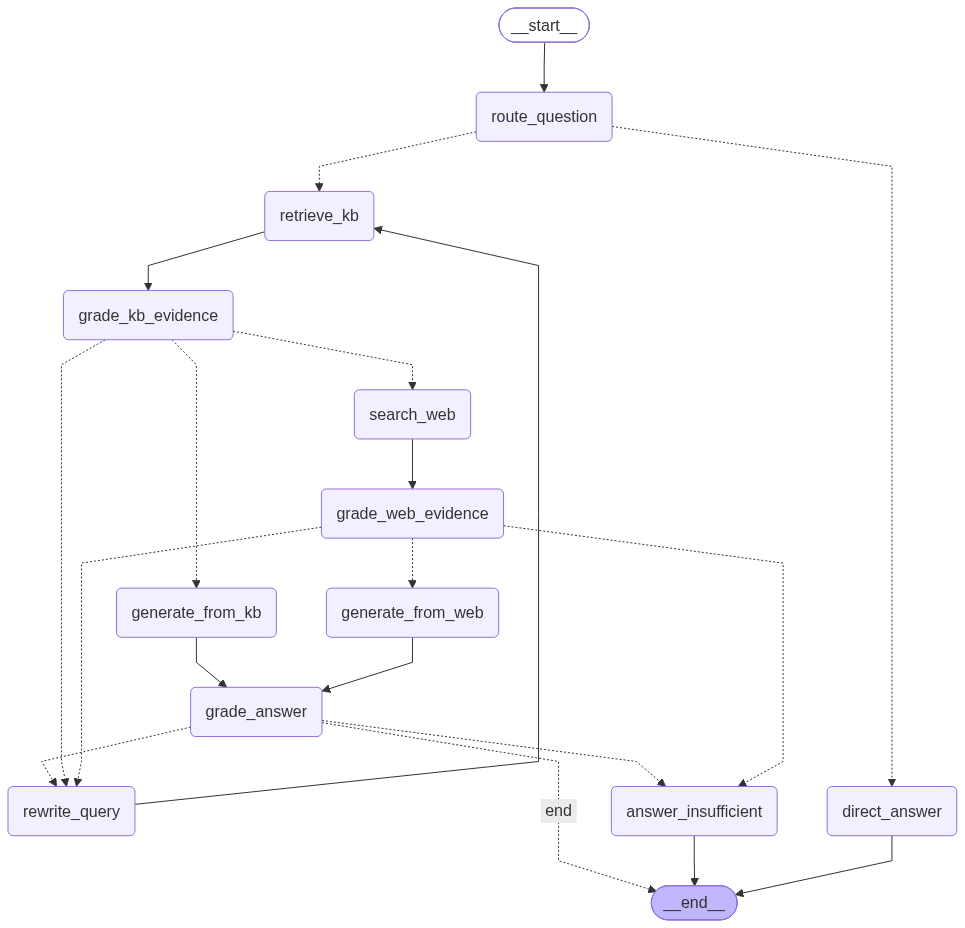

In [270]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is optional. The graph can still run.")
    print("Reason:", e)

Step 24 — Initialize the state correctly

In [271]:
def run_agent(user_question: str):

    initial_state = {
        "question": user_question,
        "current_query": user_question,

        "kb_docs": [],
        "web_results": "",

        "kb_grade": "weak",
        "kb_relevance_score": 0.0,

        "web_grade": "weak",
        "web_relevance_score": 0.0,

        "answer": "",
        "source_used": "none",

        "groundedness_score": 0.0,
        "completeness_score": 0.0,
        "citation_score": 0.0,

        "answer_grade": "retry",
        "answer_feedback": "",

        "retry_count": 0,
        "max_retries": 2
    }

    result = app.invoke(
        initial_state,
        config={"recursion_limit": 50}
    )

    return result

In [278]:
# calling the code 

result = run_agent(
    "How does Self-RAG improve Agentic RAG?"
)

print(result["answer"])

[Router] Question: How does Self-RAG improve Agentic RAG?
[Router] Decision: kb
[KB Retriever] Query: How does Self-RAG improve Agentic RAG?
[KB Retriever] Retrieved candidates: 15
[Reranker] Selected: 5 documents
[Reranker] #1 score=-3.4788
[Reranker] #2 score=-3.4788
[Reranker] #3 score=-3.7018
[Reranker] #4 score=-3.7018
[Reranker] #5 score=-3.7018
[KB Grader]
Grade: weak
Score: 0.2
Reason: The evidence consists of generic documentation about Agentic RAG from LangChain, but it does not mention Self‑RAG or explain how Self‑RAG improves Agentic RAG. Therefore the evidence is irrelevant and insufficient to answer the question.
[Query Rewriter] Original: How does Self-RAG improve Agentic RAG?
[Query Rewriter] Rewritten: How does Self‑RAG enhance the retrieval and generation pipeline of Agentic RAG, specifically in terms of query expansion, relevance scoring, and hallucination mitigation?
[KB Retriever] Query: How does Self‑RAG enhance the retrieval and generation pipeline of Agentic RAG

KeyboardInterrupt: 